In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


### Objective:- Explore Support Vector Machine Kernels and how they can be used to engineer features for a non-linear dataset 

In [93]:
# Create a non linear dataset with two features
# outer coordinates
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)

y = np.hstack([y, -y])
x = np.hstack([x, -x])


In [94]:
# inner coordinates
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)

y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

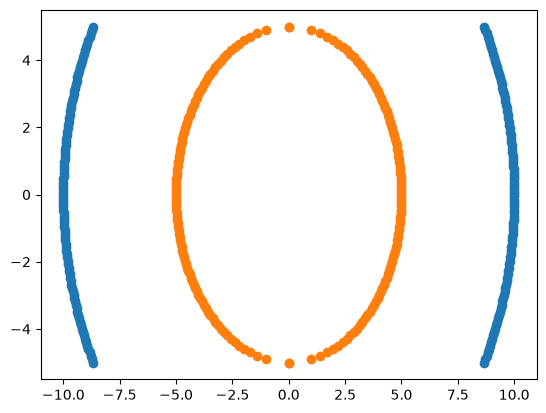

In [95]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [96]:
df1 = pd.DataFrame(np.vstack([y,x]).T, columns=['X1', 'X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1,x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1

df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [97]:
X, y = df.iloc[:, :2], df['Y']

In [98]:
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(X, y, test_size=0.25, random_state=10)

In [99]:
# Polynomial transformation
# let's manually create feature for learning purpose rather than using inbuilt poly kernel

df['X1_Square'], df['X2_Square'], df['X1*X2'] = df['X1'] ** 2, df['X2'] **2, df['X1'] * df['X2']
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [100]:
X, y = df.drop('Y', axis=1), df['Y'] 

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

### First let's plot actual data points (non-linear data) in 3D to show that there's clearly no easy way of drawing a best-fit-line/plane for solving classification/regression problems

In [102]:
pio.renderers.default = 'notebook_connected'
fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2', color='Y')
fig.show()

### In the next figure you can clearly see after applying Polynomial kernel and engineering the existing features, we can now easily separate the data by dependent feature for a machine learning algorithm.

In [103]:
pio.renderers.default = 'notebook_connected'
fig = px.scatter_3d(df, x='X1_Square', y='X2_Square', z='X1*X2', color='Y')
fig.show()

In [104]:
# Let's see what kind of accuracy can we achieve with polynomial feature engineering technique
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(accuracy_score(y_test, y_pred))

1.0


In [105]:
#Let's run same with our original dataset(non linear)
classifier = SVC(kernel='linear')
classifier.fit(X_train_non_linear, y_train_non_linear)
y_pred = classifier.predict(X_test_non_linear)
print(accuracy_score(y_test_non_linear, y_pred))

0.44


In [106]:
#Let's run same with our original dataset(non linear) with inbuilt poly kernel and degree=2 which is the same as the manul feature engineering we performed on the dataset 
classifier = SVC(kernel='poly', degree=2)
classifier.fit(X_train_non_linear, y_train_non_linear)
y_pred = classifier.predict(X_test_non_linear)
print(accuracy_score(y_test_non_linear, y_pred))

1.0


In [107]:
#Let's run same with our original dataset(non linear) with RBF kernel
classifier = SVC(kernel='rbf')
classifier.fit(X_train_non_linear, y_train_non_linear)
y_pred = classifier.predict(X_test_non_linear)
print(accuracy_score(y_test_non_linear, y_pred))

1.0


## Conclusion:- We can clearly see that a feature engineered dataset with a kernel like Poly/RBF will have much better accuracy for a non-linear dataset. It basically converts non-linear features into a linear pattern which is easily separable for making predictions